# Example of safe absorbing states

#### Control Synthesis from Linear Temporal Logic Specifications using Model-Free Reinforcement Learning

Page 6, the first example

In [1]:
%matplotlib inline
from mdp import GridMDP
from oa import OmegaAutomaton
from controlsyn import ControlSynthesis
import numpy as np 
from IPython.display import display, Image

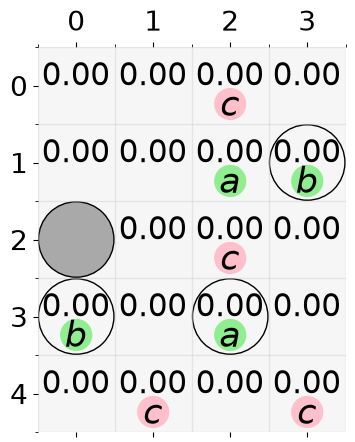

In [2]:

# MDP Description
shape = n_cols, n_rows = (5,4)
# E: Empty, T: Trap, B: Obstacle. if U, D, R or L, that means the robot cannot move towards the opposite direction
structure = np.array([
['E',  'E',  'E',  'E'],
['E',  'E',  'E',  'T'],
['B',  'E',  'E',  'E'],
['T',  'E',  'T',  'E'],
['E',  'E',  'E',  'E']
])

# Labels of the states
label = np.array([
[(),       (),     ('c',),()],
[(),       (),     ('a',),('b',)],
[(),       (),     ('c',),()],
[('b',),   (),     ('a',),()],
[(),       ('c',), (),    ('c',)]
],dtype=object)
# Colors of the labels
lcmap={
    ('a',):'lightgreen',
    ('b',):'lightgreen',
    ('c',):'pink'
}
grid_mdp = GridMDP(shape=shape,structure=structure,label=label,lcmap=lcmap,figsize=5)  # Use figsize=4 for smaller figures
grid_mdp.plot()
# Big circle means trap state. There are totally three trap states.


In [3]:
# properties of grid_mdp

print(grid_mdp.shape)        # size of MDP
print(grid_mdp.random_state())  # generate a state randomly

#actions
print(grid_mdp.A)

# trainsition matrix
for state in grid_mdp.states():
    for action, action_name in enumerate(grid_mdp.A):
        print(state, action, action_name, grid_mdp.transition_probs[state][action])

# rewards doesn't assigned (then zeros)
print(grid_mdp.reward)

# labels are given
print(grid_mdp.label)

(5, 4)
(4, 3)
['U', 'D', 'R', 'L']
(0, 0) 0 U ([(0, 1), (0, 0)], [0.09999999999999998, np.float64(0.9)])
(0, 0) 1 D ([(1, 0), (0, 1), (0, 0)], [0.8, 0.09999999999999998, np.float64(0.09999999999999998)])
(0, 0) 2 R ([(1, 0), (0, 1), (0, 0)], [0.09999999999999998, 0.8, np.float64(0.09999999999999998)])
(0, 0) 3 L ([(1, 0), (0, 0)], [0.09999999999999998, np.float64(0.9)])
(0, 1) 0 U ([(0, 0), (0, 2), (0, 1)], [0.09999999999999998, 0.09999999999999998, np.float64(0.8)])
(0, 1) 1 D ([(1, 1), (0, 0), (0, 2)], [0.8, 0.09999999999999998, 0.09999999999999998])
(0, 1) 2 R ([(1, 1), (0, 2), (0, 1)], [0.09999999999999998, 0.8, np.float64(0.09999999999999998)])
(0, 1) 3 L ([(1, 1), (0, 0), (0, 1)], [0.09999999999999998, 0.8, np.float64(0.09999999999999998)])
(0, 2) 0 U ([(0, 1), (0, 3), (0, 2)], [0.09999999999999998, 0.09999999999999998, np.float64(0.8)])
(0, 2) 1 D ([(1, 2), (0, 1), (0, 3)], [0.8, 0.09999999999999998, 0.09999999999999998])
(0, 2) 2 R ([(1, 2), (0, 3), (0, 2)], [0.0999999999999999

Number of Omega-automaton states (including the trap state): 4
Initial state: 0
Transition function: [
  {(): 0, ('a',): 0, ('b',): 0, ('c',): 3, ('a', 'b'): 0, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3},
  {(): 3, ('a',): 1, ('b',): 3, ('c',): 3, ('a', 'b'): 1, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3},
  {(): 3, ('a',): 3, ('b',): 2, ('c',): 3, ('a', 'b'): 2, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3},
  {(): 3, ('a',): 3, ('b',): 3, ('c',): 3, ('a', 'b'): 3, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3}
]
Transition from state 0 taking 'c' reaches state 3
Epsilon transition: [
  [1, 2],
  [],
  [],
  []
]
(transition-based) Acceptance: [
  {(): [None], ('a',): [None], ('b',): [None], ('c',): [None], ('a', 'b'): [None], ('a', 'c'): [None], ('b', 'c'): [None], ('a', 'b', 'c'): [None]},
  {(): [None], ('a',): [True], ('b',): [None], ('c',): [None], ('a', 'b'): [True], ('a', 'c'): [None], ('b', 'c'): [None], ('a', 'b', 'c'): [None]},
  {(): [None], ('a',): [Non

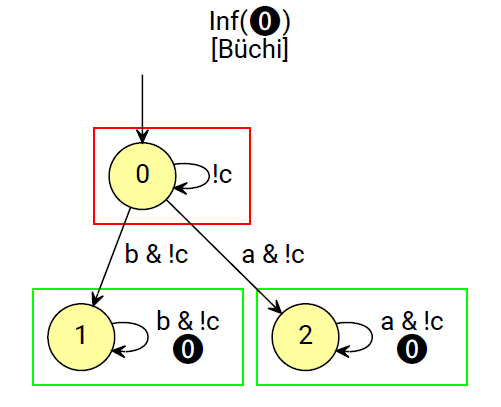

In [4]:
# LTL Specification
ltl = '(F G a | F G b) & G !c'

# Translate the LTL formula to an LDBA
oa = OmegaAutomaton(ltl, 'ldba')
print('Number of Omega-automaton states (including the trap state):',oa.shape[1])
print('Initial state:',oa.q0)
print('Transition function: ['),print(*['  '+str(t) for t in oa.delta],sep=',\n'),print(']')
# oa.delta is a list of dictionaries
# 0-()->0; 0-a->0; 0-b->0; 0-c->3; 0-a,b->0, 0-a,c->3, 0-b,c->3, 0-a,b,c->3
# 1-()->3; 1-a->3;...
# for example, to express the transition from 0 taking 'c'
print('Transition from state 0 taking \'c\' reaches state', oa.delta[0][('c',)])

print('Epsilon transition: ['),print(*['  '+str(t) for t in oa.eps],sep=',\n'),print(']')
# 0-eps->1; 0-eps->2; no for states 1, 2, 3

print('(transition-based) Acceptance: ['),print(*['  '+str(t) for t in oa.acc],sep=',\n'),print(']')

# automaton from owl website https://owl.model.in.tum.de/try/
Image("3-ldba-owl.png", width=250)


Transition function: [
  {(): 0, ('a',): 0, ('b',): 0, ('c',): 3, ('a', 'b'): 0, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3},
  {(): 3, ('a',): 1, ('b',): 3, ('c',): 3, ('a', 'b'): 1, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3},
  {(): 3, ('a',): 3, ('b',): 2, ('c',): 3, ('a', 'b'): 2, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3},
  {(): 3, ('a',): 3, ('b',): 3, ('c',): 3, ('a', 'b'): 3, ('a', 'c'): 3, ('b', 'c'): 3, ('a', 'b', 'c'): 3}
]
Epsilon transition: [
  [1, 2],
  [],
  [],
  []
]


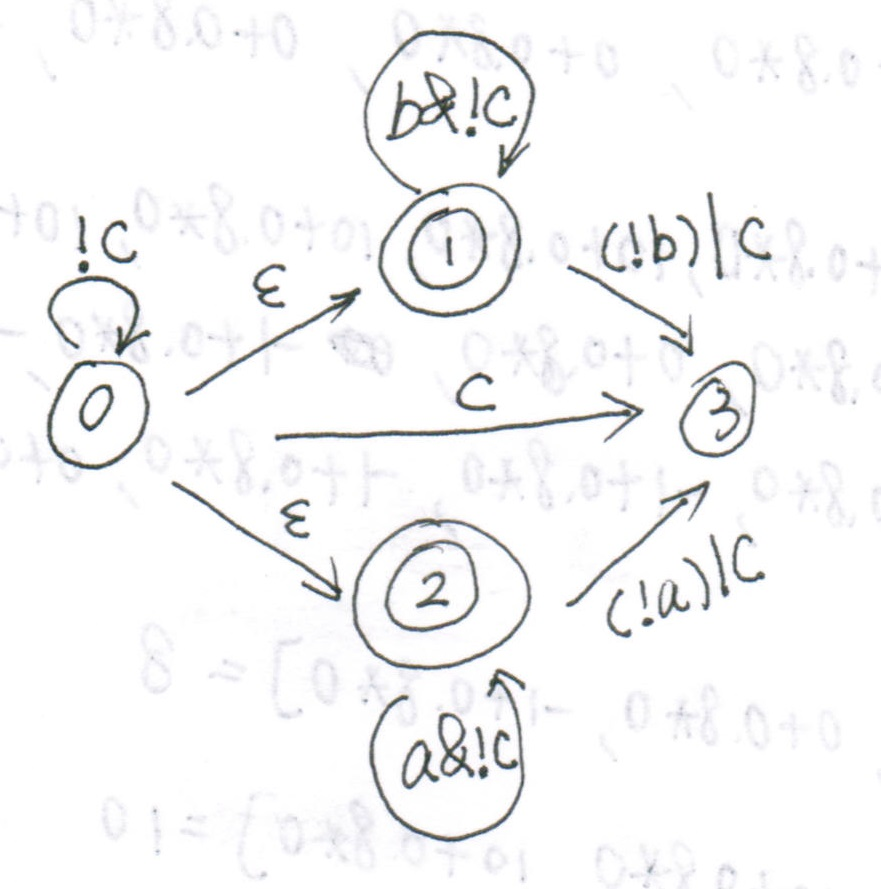

In [5]:

print('Transition function: ['),print(*['  '+str(t) for t in oa.delta],sep=',\n'),print(']')
# 0-()->0; 0-a->0; 0-b->0; 0-c->3; 0-a,b->0, 0-a,c->3, 0-b,c->3, 0-a,b,c->3
# 1-()->3; 1-a->3;...

print('Epsilon transition: ['),print(*['  '+str(t) for t in oa.eps],sep=',\n'),print(']')
# 0-eps->1; 0-eps->2; no for states 1, 2, 3

# automaton from rainibizer. It is the one used in this example
Image("3-ldba-ran.jpg", width=250)

In [6]:
# Construct the product MDP
csrl = ControlSynthesis(grid_mdp,oa)

In [7]:
print(oa.shape)     # oa.shape[1] is the number of states
print(grid_mdp.shape)
print(csrl.shape)
print(csrl.shape[:-1])  # this is size of states in product MDP (1,4,5,4)
#(,8) supposes to be the number of actions  (len(grid_mdp.A)+oa.shape[1])
print(grid_mdp.A)
print(oa.shape[1])

(1, 4)
(5, 4)
(1, 4, 5, 4, 8)
(1, 4, 5, 4)
['U', 'D', 'R', 'L']
4


In [8]:
# In product MDP, states are represented by [i,q,r,c] where q is the number of states in the automaton,
# [r, c] represents the states of MDP, i.e., # of rows, # of columns
# i is the number of MDPs. (for multi-agent?)

for i,q,r,c in csrl.states():
    None
    #print(i, q, r, c)      # if printed (need to comment "None"), i=0, q=0->3, r=0->4, c=0->3     

In [9]:
print(csrl.A.shape) # automaton size (1,4) x MDP size (5,4)
# every element of csrl.A[i,q,r,c] is a list of possible actions

# examples,

print(csrl.A[0,0,0,0]) # the first 0 represent the first agent (i.e., the first MDP) 
#the second 0 represents q0, the last two 0s represent MDP state (0,0). 
# the list of possible actions in this product MDP state has [0,1,2,3] for "U D R L" and [5,6] for epsilon (to q1 and q2)

print(csrl.A[0,1,0,0]) 
# q1 (the second 1) doesn't have epsilon actions so the list of possible actions only has ["U D R L"]

(1, 4, 5, 4)
[0, 1, 2, 3, 5, 6]
[0, 1, 2, 3]


In [10]:
# transition probability

for action in csrl.A[0,0,0,0]:
    print(csrl.transition_probs[0,0,0,0][action])
 
# the first four actions (in MDP) result in the same probs (see below). 
#The last two actions are for epilson-trainsition in LDBA
#(0, 0) 0 U ([(0, 1), (0, 0)], [0.09999999999999998, 0.9])
#(0, 0) 1 D ([(1, 0), (0, 1), (0, 0)], [0.8, 0.09999999999999998, 0.09999999999999998])
#(0, 0) 2 R ([(1, 0), (0, 1), (0, 0)], [0.09999999999999998, 0.8, 0.09999999999999998])
#(0, 0) 3 L ([(1, 0), (0, 0)], [0.09999999999999998, 0.9])

([(0, 0, 0, 1), (0, 0, 0, 0)], [0.09999999999999998, np.float64(0.9)])
([(0, 0, 1, 0), (0, 0, 0, 1), (0, 0, 0, 0)], [0.8, 0.09999999999999998, np.float64(0.09999999999999998)])
([(0, 0, 1, 0), (0, 0, 0, 1), (0, 0, 0, 0)], [0.09999999999999998, 0.8, np.float64(0.09999999999999998)])
([(0, 0, 1, 0), (0, 0, 0, 0)], [0.09999999999999998, np.float64(0.9)])
([(0, 1, 0, 0)], [1.0])
([(0, 2, 0, 0)], [1.0])


In [11]:
# rewards, print non-zero reward and the corresponding product MDP states. Other rewards are zeros. 
# the rewards are based on LDBA accepting sets, and the label of MDP state

print('(transition-based) Acceptance: ['),print(*['  '+str(t) for t in oa.acc],sep=',\n'),print(']')

for i,q,r,c in csrl.states():
    if csrl.reward[i, q, r, c] > 1.e-9:
        print((i,q,r, c), csrl.reward[i, q, r, c])


        
# ignore the first digit 0, because it is only one agent
# the second digit 1 means q1 in LDBA, 2 means q2 in LDBA
# at q1, (1,3) and (3,0) are labeled with ('b',)
# at q2, (1,2) and (3,1) are labeled with ('a',) 

print('generating a random state', csrl.random_state())
# it just generates a randome state of product MDP. 
# It is not the initial random state, which shall be (0, 0, *, *)

(transition-based) Acceptance: [
  {(): [None], ('a',): [None], ('b',): [None], ('c',): [None], ('a', 'b'): [None], ('a', 'c'): [None], ('b', 'c'): [None], ('a', 'b', 'c'): [None]},
  {(): [None], ('a',): [True], ('b',): [None], ('c',): [None], ('a', 'b'): [True], ('a', 'c'): [None], ('b', 'c'): [None], ('a', 'b', 'c'): [None]},
  {(): [None], ('a',): [None], ('b',): [True], ('c',): [None], ('a', 'b'): [True], ('a', 'c'): [None], ('b', 'c'): [None], ('a', 'b', 'c'): [None]},
  {(): [None], ('a',): [None], ('b',): [None], ('c',): [None], ('a', 'b'): [None], ('a', 'c'): [None], ('b', 'c'): [None], ('a', 'b', 'c'): [None]}
]
(0, 1, 1, 2) 0.010000000000000009
(0, 1, 3, 2) 0.010000000000000009
(0, 2, 1, 3) 0.010000000000000009
(0, 2, 3, 0) 0.010000000000000009
generating a random state (0, 3, 2, 0)


In [12]:
Q=csrl.q_learning(T=25,K=10000)  # model-free RL 
# the original code chose T=100, K=100,000
# using smaller numbers here saves computation time. However, it may not be converged. 

0
5000
10000


In [13]:
print('action-statave (Q) values:')
#for state in csrl.states():
#    print(state)
#    for action in csrl.A[state]:
#        print("    action {}".format(action), Q[state][action])


action-statave (Q) values:


In [14]:
print("state values:")
value=np.max(Q,axis=4)
#for state in csrl.states():
#    print(state, value[state])

state values:


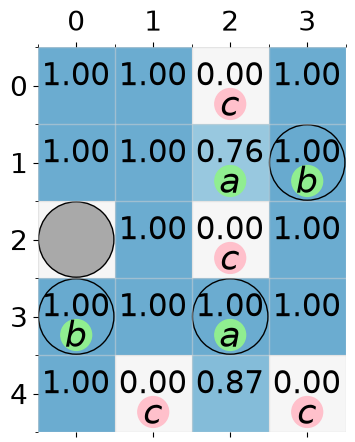

In [15]:
# csrl.plot(value,iq=(0,0),save='safe_absorbing_states_values.pdf')
csrl.plot(value,iq=(0,0)) # only plot value [0,0]

In [16]:
policy=csrl.greedy_policy(value)
policy = np.argmax(Q, axis=4)
#for state in csrl.states():
#    print(state, policy[state])

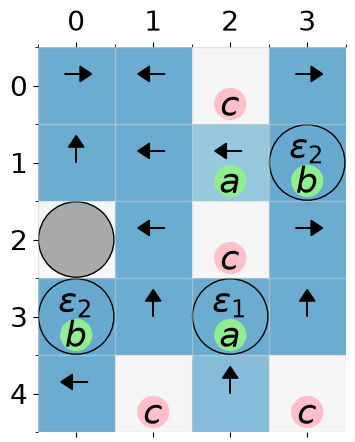

In [17]:

# csrl.plot(value,policy,iq=(0,0),save='safe_absorbing_states_policy.pdf')
csrl.plot(value,policy,iq=(0,0))   # only plot policy[0,0]

In [18]:
# episode=csrl.simulate(value, policy,start=(0,0),T=300, animation = False)

# if set animation=True, "safeAbsorbingStates.mp4" will be generated.
# However, you need to create an "animation" folder before running this code. 
# The "animation" folder will save the .png files, which are then used to generate the movie in the current folder.

In [19]:
H=csrl.reinforce(T=25,K=10000)  # model-free RL 


0
5000
10000


In [20]:
valueR=np.max(H,axis=4)


In [21]:
policyR = csrl.policy_from_H(H)


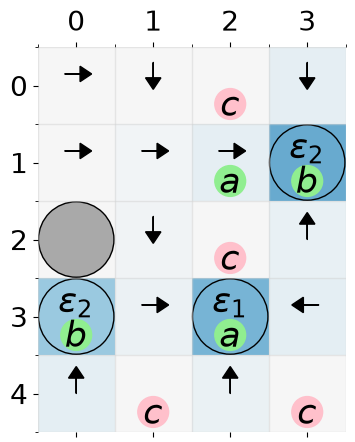

In [22]:
csrl.plot(value=valueR, policy=policyR, iq=(0, 0))   # only plot policy[0,0]

0
0
0
0
0
5000
0
5000
0
5000
10000
0
5000
10000
0
5000
10000
15000
20000
25000
0
5000
10000
15000
20000
25000
0
5000
10000
15000
20000
25000
30000
35000
40000
0
5000
10000
15000
20000
25000
30000
35000
40000
0
5000
10000
15000
20000
25000
30000
35000
40000
45000
50000
0
5000
10000
15000
20000
25000
30000
35000
40000
45000
50000


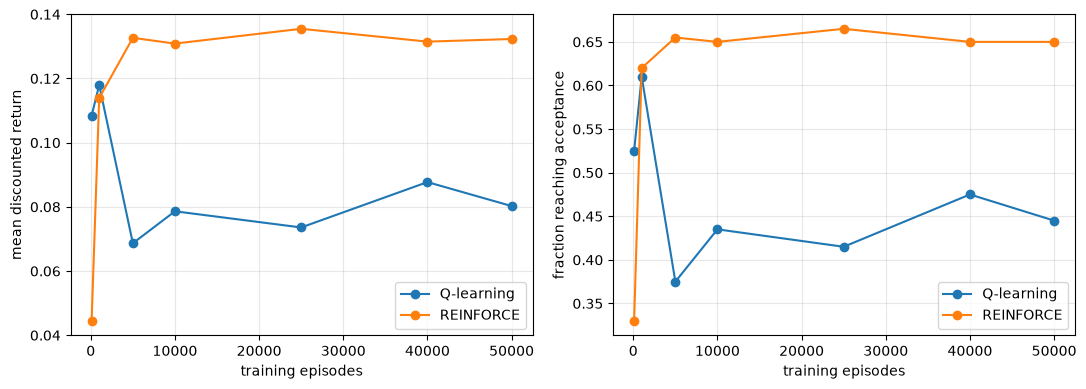

In [24]:
results = csrl.compare_learning(
    checkpoints=[100, 1000, 5000, 10000, 25000, 40000, 50000],
    T=25,
    eval_episodes=200,
    seed=0,
    plot=True
)